# DUO: Transfer Learning A/B/C — YOLOv8s

Сравниваем три модели на DUO test:

- **baseline** — YOLOv8s, стартовые веса COCO (`yolov8s.pt`), fine-tune на DUO.
- **transfer** — YOLOv8s, стартовые веса от Brackish-предобучения с **weak** аугментацией, fine-tune на DUO.
- **transfer_strong** — YOLOv8s, стартовые веса от Brackish-предобучения со **strong** аугментацией, fine-tune на DUO.

Гиперпараметры fine-tuning идентичны во всех трёх (см. соответствующие train-ноутбуки). Разница в результате — эффект источника предобучения: COCO vs Brackish/weak vs Brackish/strong.

Что смотрим: глобальные mAP, per-class AP, PR-кривые, скорость инференса и кривые сходимости (быстрее ли transfer-модели выходят на плато).

In [26]:
%matplotlib inline
import os
from pathlib import Path
from ultralytics import YOLO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if Path.cwd().name == "notebooks":
    os.chdir("..")
print(f"Working dir: {Path.cwd()}")

Working dir: d:\Slermo\Programming\Python\yolo_marine


## Реестр моделей

Берём свежайший `best.pt` из подходящих ранов (ultralytics автоинкрементит имена при повторных запусках).

In [27]:
import re

def latest(glob_pattern: str) -> Path:
    matches = sorted(Path(".").glob(glob_pattern), key=lambda p: p.stat().st_mtime)
    if not matches:
        raise FileNotFoundError(f"Не найдено: {glob_pattern}")
    return matches[-1]

# Ultralytics иногда вкладывает прогоны под detect/ — глобим оба варианта.
def latest_any(*patterns: str) -> Path:
    candidates = []
    for p in patterns:
        candidates.extend(Path(".").glob(p))
    if not candidates:
        raise FileNotFoundError(f"Не найдено по паттернам: {patterns}")
    return sorted(candidates, key=lambda p: p.stat().st_mtime)[-1]

def find_run(run_name: str, kind: str) -> Path:
    candidates = []
    for base in (
        "runs/detect/runs/duo_yolov8s",
        "runs/detect/runs/duo_yolov8s/detect",
        "runs/detect/runs/detect/duo_yolov8s",
    ):
        for p in Path(base).glob(f"{run_name}*"):
            # Принимаем только точное имя или имя + цифры (transfer, transfer2, transfer3)
            if re.fullmatch(rf"{re.escape(run_name)}\d*", p.name):
                candidate = p / kind
                if candidate.exists():
                    candidates.append(candidate)
    if not candidates:
        raise FileNotFoundError(f"Не найдено: {run_name}/{kind}")
    return sorted(candidates, key=lambda p: p.stat().st_mtime)[-1]

RUN_NAMES = ["baseline", "transfer", "transfer_strong"]

MODELS = {name: find_run(name, "weights/best.pt") for name in RUN_NAMES}

COLORS = {
    "baseline":        "#5B8CF5",  # blue
    "transfer":        "#E05C5C",  # red
    "transfer_strong": "#42B883",  # green
}

for name, path in MODELS.items():
    print(f"{name:16s} -> {path}")

baseline         -> runs\detect\runs\duo_yolov8s\baseline\weights\best.pt
transfer         -> runs\detect\runs\duo_yolov8s\transfer3\weights\best.pt
transfer_strong  -> runs\detect\runs\duo_yolov8s\transfer_strong\weights\best.pt


## Прогон test-валидации

In [28]:
results = {}
for name, weights in MODELS.items():
    print(f"\n=== {name} ===")
    model = YOLO(str(weights))
    m = model.val(
        data="configs/dataset_duo.yaml",
        split="test",
        batch=1,
        device=0,
        plots=False,
        verbose=False,
    )

    pr_curve = None
    for x, y, xlabel, ylabel in m.box.curves_results:
        if xlabel == "Recall" and ylabel == "Precision":
            pr_curve = (np.asarray(x), np.asarray(y))  # y: (num_classes, num_points)
            break

    results[name] = {
        "weights":           weights,
        "mAP@50":            float(m.box.map50),
        "mAP@50-95":         float(m.box.map),
        "Precision":         float(m.box.mp),
        "Recall":            float(m.box.mr),
        "speed_ms":          float(m.speed["inference"]),
        "per_class_ap50":    {n: float(m.box.ap50[i]) for i, n in m.names.items()},
        "per_class_ap5095":  {n: float(m.box.ap[i])   for i, n in m.names.items()},
        "class_names":       [m.names[i] for i in sorted(m.names)],
        "pr_curve":          pr_curve,
    }
    print(f"  mAP@50 = {results[name]['mAP@50']:.4f}  mAP@50-95 = {results[name]['mAP@50-95']:.4f}")


=== baseline ===
Ultralytics 8.4.19  Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16310MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 834.91154.3 MB/s, size: 437.7 KB)
val: Scanning D:\Slermo\Programming\Python\yolo_marine\data\DUO\yolo\labels\test.cache... 1111 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1111/1111  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1111/1111 71.5it/s 15.5s<0.1s
                   all       1111      10517      0.836       0.79      0.847      0.674
Speed: 1.0ms preprocess, 8.9ms inference, 0.0ms loss, 1.4ms postprocess per image
  mAP@50 = 0.8472  mAP@50-95 = 0.6743

=== transfer ===
Ultralytics 8.4.19  Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16310MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast

## Сводная таблица

In [29]:
summary = pd.DataFrame({
    name: {
        "mAP@50":        r["mAP@50"],
        "mAP@50-95":     r["mAP@50-95"],
        "Precision":     r["Precision"],
        "Recall":        r["Recall"],
        "inference, ms": r["speed_ms"],
    }
    for name, r in results.items()
}).T

# Δ vs baseline для каждой transfer-модели (положительное = transfer лучше).
delta_rows = {}
if "baseline" in summary.index:
    for name in summary.index:
        if name == "baseline":
            continue
        delta_rows[f"Δ {name} − baseline"] = summary.loc[name] - summary.loc["baseline"]

if delta_rows:
    summary = pd.concat([summary, pd.DataFrame(delta_rows).T])

delta_idx = [i for i in summary.index if i.startswith("Δ ")]
base_idx  = [i for i in summary.index if not i.startswith("Δ ")]

styler = summary.style.format("{:.4f}", subset=pd.IndexSlice[base_idx, :])
if delta_idx:
    styler = styler.format("{:+.4f}", subset=pd.IndexSlice[delta_idx, :])
styler

,mAP@50,mAP@50-95,Precision,Recall,"inference, ms"
baseline,0.8472,0.6743,0.8355,0.7901,8.8983
transfer,0.8325,0.6525,0.8091,0.7748,7.6501
transfer_strong,0.8395,0.6574,0.8581,0.7455,7.7850
Δ transfer − baseline,-0.0147,-0.0218,-0.0264,-0.0153,-1.2482
Δ transfer_strong − baseline,-0.0077,-0.0169,+0.0226,-0.0446,-1.1133


## Глобальные метрики

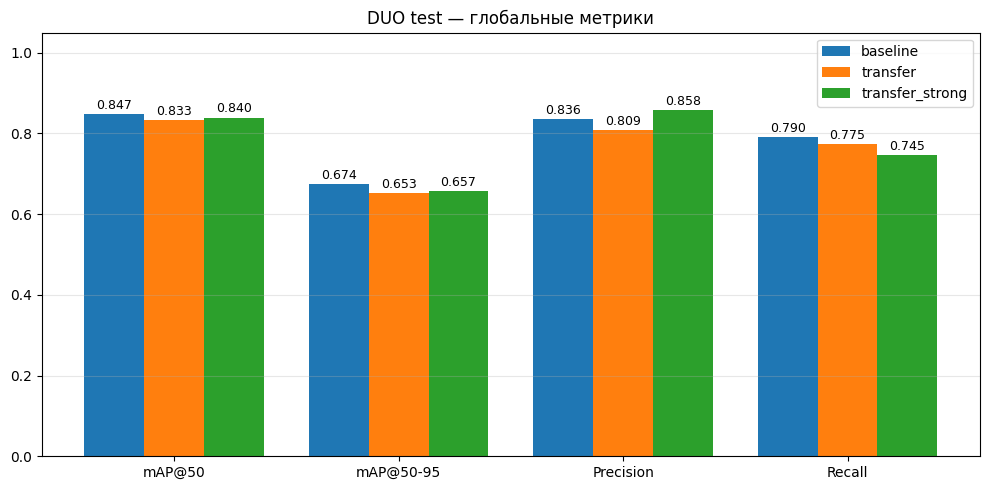

In [30]:
METRICS = ["mAP@50", "mAP@50-95", "Precision", "Recall"]
names = list(results.keys())
x = np.arange(len(METRICS))
width = 0.8 / len(names)

fig, ax = plt.subplots(figsize=(10, 5))
for i, name in enumerate(names):
    vals = [results[name][m] for m in METRICS]
    bars = ax.bar(x + i * width - 0.4 + width / 2, vals, width, label=name)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.005, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(METRICS)
ax.set_ylim(0, 1.05)
ax.set_title("DUO test — глобальные метрики")
ax.grid(True, alpha=0.3, axis="y")
ax.legend()
plt.tight_layout()
plt.show()

## Per-class сравнение

AP@50 — «находит ли вообще», AP@50-95 — точность локализации. Если transfer выигрывает в первом, но не во втором — он лучше детектит, но не точнее по бокс-координатам.

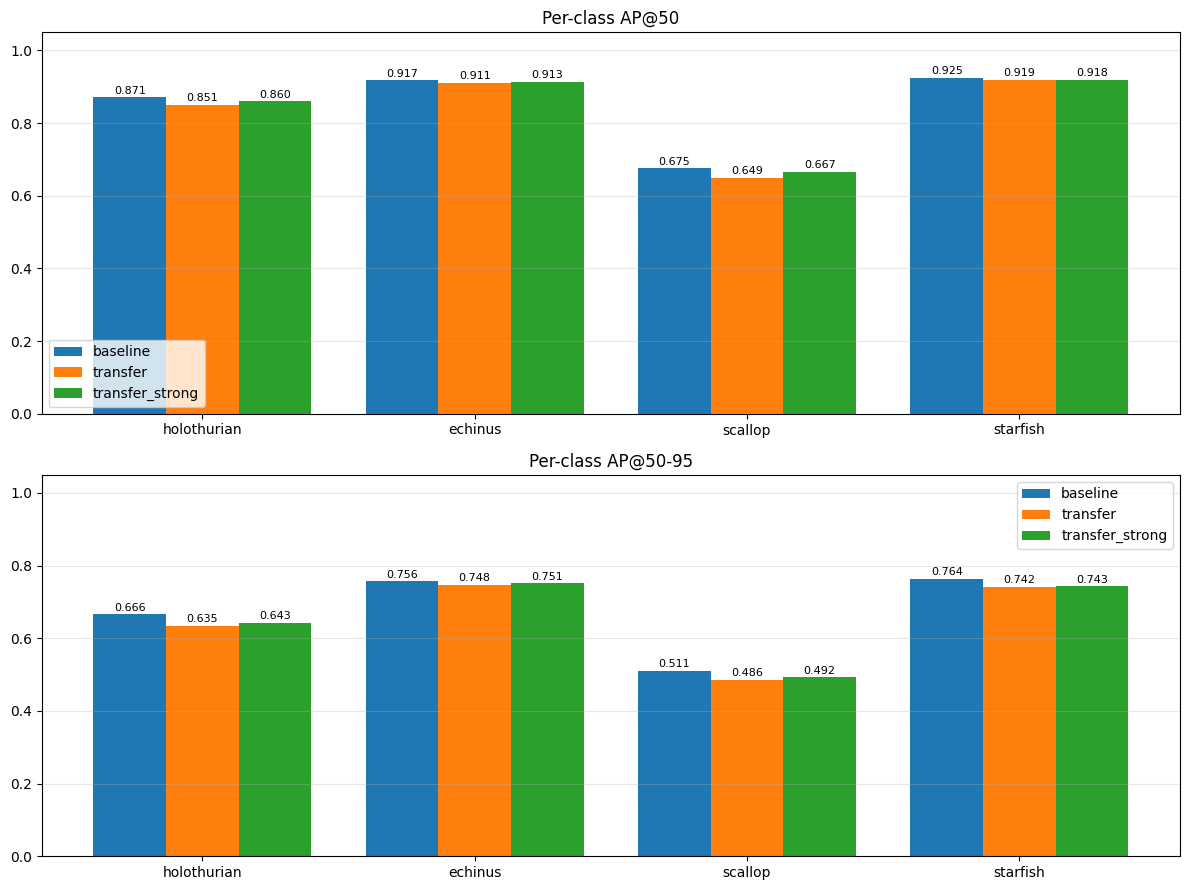

In [31]:
classes = list(next(iter(results.values()))["per_class_ap50"].keys())
x = np.arange(len(classes))
width = 0.8 / len(names)

fig, axes = plt.subplots(2, 1, figsize=(12, 9))
for ax, key, title in zip(
    axes,
    ["per_class_ap50", "per_class_ap5095"],
    ["Per-class AP@50", "Per-class AP@50-95"],
):
    for i, name in enumerate(names):
        vals = [results[name][key][c] for c in classes]
        bars = ax.bar(x + i * width - 0.4 + width / 2, vals, width, label=name)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.005, f"{v:.3f}",
                    ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis="y")
    ax.legend()

plt.tight_layout()
plt.show()

## PR-кривые

Усреднённая по классам, потом per-class сетка. Если две модели имеют близкий mAP, но разные формы кривых — они по-разному ошибаются (одна жертвует recall, другая precision).

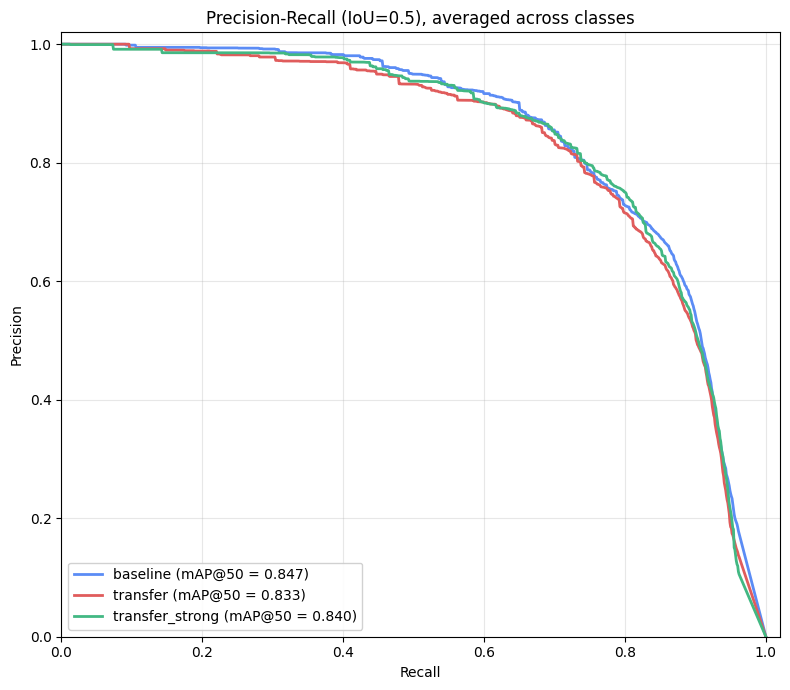

In [32]:
fig, ax = plt.subplots(figsize=(8, 7))
for name, r in results.items():
    if r["pr_curve"] is None:
        continue
    recall, precision_per_class = r["pr_curve"]
    precision_avg = precision_per_class.mean(axis=0)
    ax.plot(
        recall, precision_avg,
        label=f"{name} (mAP@50 = {r['mAP@50']:.3f})",
        color=COLORS.get(name),
        linewidth=2,
    )

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall (IoU=0.5), averaged across classes")
ax.legend(loc="lower left", framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

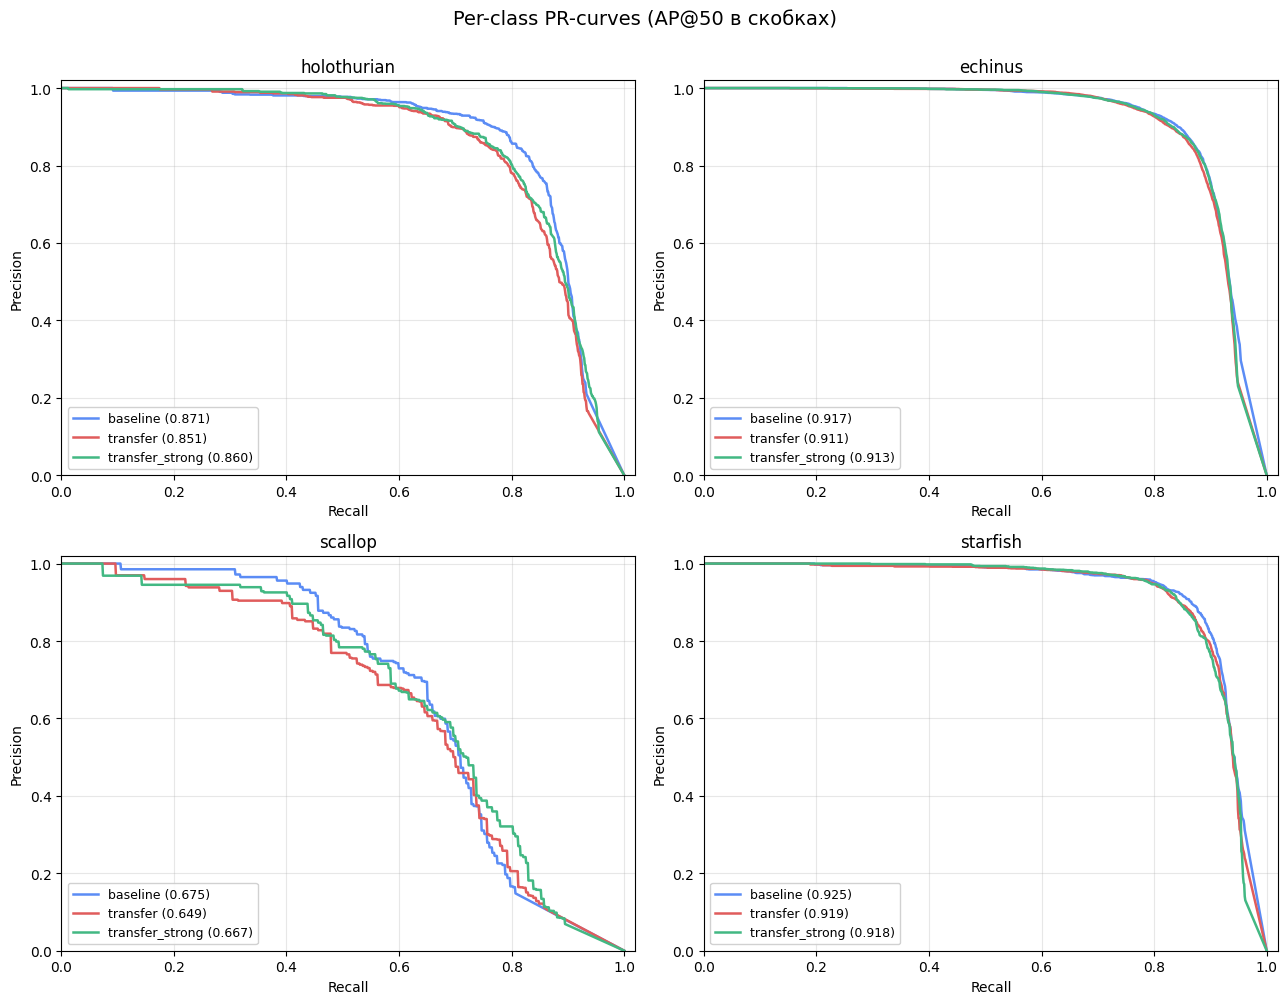

In [33]:
classes = next(iter(results.values()))["class_names"]
n_classes = len(classes)
ncols = 2
nrows = (n_classes + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(13, 5 * nrows), squeeze=False)
for ci, cname in enumerate(classes):
    ax = axes[ci // ncols][ci % ncols]
    for name, r in results.items():
        if r["pr_curve"] is None:
            continue
        recall, precision_per_class = r["pr_curve"]
        ap50 = r["per_class_ap50"][cname]
        ax.plot(
            recall, precision_per_class[ci],
            label=f"{name} ({ap50:.3f})",
            color=COLORS.get(name),
            linewidth=1.8,
        )
    ax.set_title(cname)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.02)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower left", fontsize=9, framealpha=0.9)

for k in range(n_classes, nrows * ncols):
    axes[k // ncols][k % ncols].axis("off")

plt.suptitle("Per-class PR-curves (AP@50 в скобках)", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

## Кривые сходимости (train log)

Главный признак, что Brackish-предобучение помогло — transfer достигает того же качества **раньше** baseline и/или **выше** на плато. Смотрим mAP@50-95 на val (это та метрика, по которой Ultralytics выбирает best.pt).

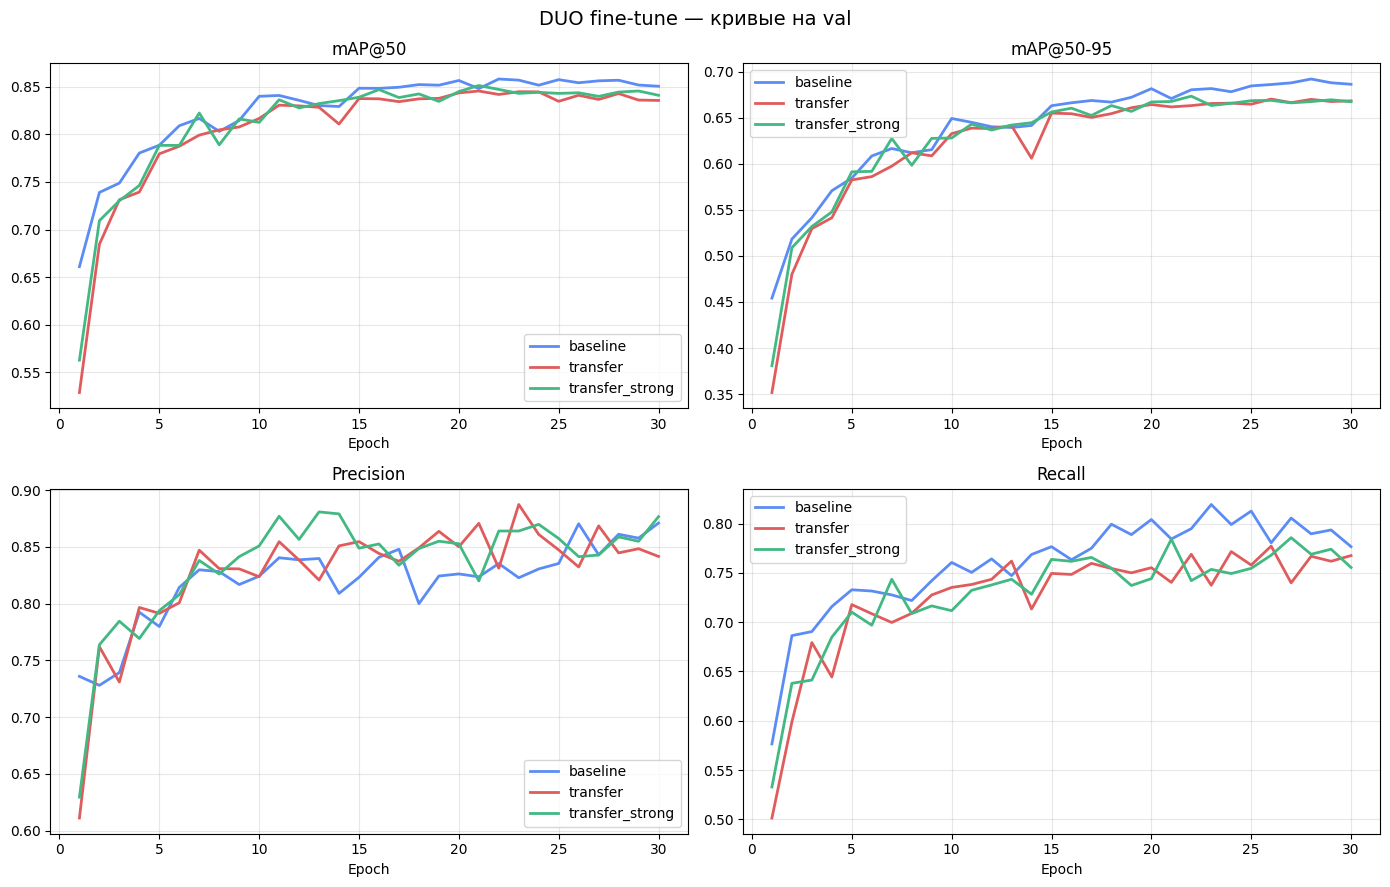


Эпоха выхода на best mAP@50-95:
  baseline        : epoch 28  (val mAP@50-95 = 0.6921)
  transfer        : epoch 26  (val mAP@50-95 = 0.6703)
  transfer_strong : epoch 22  (val mAP@50-95 = 0.6734)


In [34]:
logs = {name: pd.read_csv(find_run(name, "results.csv"), skipinitialspace=True) for name in names}

metric_cols = {
    "mAP@50":    "metrics/mAP50(B)",
    "mAP@50-95": "metrics/mAP50-95(B)",
    "Precision": "metrics/precision(B)",
    "Recall":    "metrics/recall(B)",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (title, col) in zip(axes.flatten(), metric_cols.items()):
    for name, df in logs.items():
        ax.plot(df["epoch"] if "epoch" in df.columns else df.index,
                df[col], label=name, color=COLORS.get(name), linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("DUO fine-tune — кривые на val", fontsize=14)
plt.tight_layout()
plt.show()

print("\nЭпоха выхода на best mAP@50-95:")
for name, df in logs.items():
    col = metric_cols["mAP@50-95"]
    best_epoch = df[col].idxmax() + 1
    best_val = df[col].max()
    print(f"  {name:16s}: epoch {best_epoch:2d}  (val mAP@50-95 = {best_val:.4f})")